In [31]:
import pandas as pd
import numpy as np
import re
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

from google.colab import files
uploaded = files.upload()

df_raw = pd.read_csv("/content/Credit_Card_Applications (2).csv")

df_raw.head()
df_raw.info()

Saving Credit_Card_Applications.csv to Credit_Card_Applications (6).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


Due to the anonymized nature of the dataset, column labels were inferred through a combination of distribution analysis, approval rate correlation, domain knowledge of credit application practices, and cross-referencing with known public datasets. All labels represent evidence-based hypotheses rather than confirmed definitions.

# A1 — Gender (0 = Male, 1 = Female)
Reasoning: Binary column with only 2 unique values. Approval rate difference of -0.013 — essentially zero — meaning the variable has almost no effect on approval outcome.

In [14]:
binary_cols = ['A1', 'A8', 'A9', 'A11']
for col in binary_cols:
    print(f"\n{col}:")
    proportions = df_raw.groupby(col)['Class'].value_counts(normalize=True).unstack()
    print(proportions)
    print(f"Approval rate difference: {abs(proportions[1].max() - proportions[1].min()):.3f}")


A1:
Class         0         1
A1                       
0      0.545045  0.454955
1      0.559829  0.440171
Approval rate difference: 0.015

A8:
Class         0         1
A8                       
0      0.930091  0.069909
1      0.213296  0.786704
Approval rate difference: 0.717

A9:
Class         0         1
A9                       
0      0.751899  0.248101
1      0.291525  0.708475
Approval rate difference: 0.460

A11:
Class         0         1
A11                      
0      0.569519  0.430481
1      0.537975  0.462025
Approval rate difference: 0.032


In [15]:
results = []

for col in df_raw.columns:
    if col == 'Class':
        continue

    n_unique = df_raw[col].nunique()
    dtype = df_raw[col].dtype
    missing = df_raw[col].isna().sum()
    col_min = df_raw[col].min() if dtype != 'object' else None
    col_max = df_raw[col].max() if dtype != 'object' else None
    col_mean = df_raw[col].mean() if dtype != 'object' else None
    has_decimals = bool((df_raw[col].dropna() % 1 != 0).any()) if dtype != 'object' else None

    approved_mean = df_raw[df_raw['Class'] == 1][col].mean() if dtype != 'object' else None
    denied_mean = df_raw[df_raw['Class'] == 0][col].mean() if dtype != 'object' else None

    if dtype == 'object':
        approval_by_cat = df_raw.groupby(col)['Class'].mean()
        approval_range = round(approval_by_cat.max() - approval_by_cat.min(), 3)
    else:
        approval_range = round(approved_mean - denied_mean, 3) if approved_mean and denied_mean else None

    results.append({
        'column': col,
        'dtype': dtype,
        'n_unique': n_unique,
        'missing': missing,
        'min': col_min,
        'max': col_max,
        'mean': round(col_mean, 3) if col_mean else None,
        'has_decimals': has_decimals,
        'approved_mean': round(approved_mean, 3) if approved_mean else None,
        'denied_mean': round(denied_mean, 3) if denied_mean else None,
        'approval_diff': approval_range
    })

summary_df = pd.DataFrame(results)
print(summary_df.to_string())

        column    dtype  n_unique  missing          min          max          mean  has_decimals  approved_mean   denied_mean  approval_diff
0   CustomerID    int64       690        0  15565714.00  15815443.00  1.569047e+07         False   1.569330e+07  1.568821e+07       5089.915
1           A1    int64         2        0         0.00         1.00  6.780000e-01         False   6.710000e-01  6.840000e-01         -0.013
2           A2  float64       350        0        13.75        80.25  3.156800e+01          True   3.370600e+01  2.985400e+01          3.852
3           A3  float64       215        0         0.00        28.00  4.759000e+00          True   5.905000e+00  3.840000e+00          2.065
4           A4    int64         3        0         1.00         3.00  1.767000e+00         False   1.860000e+00  1.692000e+00          0.168
5           A5    int64        14        0         1.00        14.00  7.372000e+00         False   8.909000e+00  6.141000e+00          2.768
6           A

# A2 — Age (Range: ~14–80)
Reasoning: Continuous float variable with 350 unique values ranging from 13.75 to 80.25. The decimal values confirm it is self-reported age rather than a computed score. Approved applicants had a mean age approximately 3.85 years older than denied applicants, consistent with older applicants having more established credit histories.

In [16]:
summary_df[summary_df['column'] == 'A2']

,column,dtype,n_unique,missing,min,max,mean,has_decimals,approved_mean,denied_mean,approval_diff
2,A2,float64,350,0,13.75,80.25,31.568,True,33.706,29.854,3.852


A3 — Years Employed (Float)
# Reasoning: Continuous float variable ranging 0–28 with 215 unique values. The decimal precision (e.g. 22.34) suggests it represents years and months of employment tenure. Approved applicants averaged 2.065 more years employed than denied applicants — a positive relationship consistent with employment stability being a creditworthiness signal.

In [17]:
df_raw.groupby('Class')['A3'].mean()


,A3
Class,
0,3.839948
1,5.904951


# A4 — Marital Status (1 = Single, 2 = Married, 3 = Divorced/Widowed)
Reasoning: Categorical variable with exactly 3 unique values ranging 1–3. Three categories with a weak approval difference of 0.168 is consistent with marital status, which is collected on credit applications but has a limited effect on approval. Three categories maps cleanly to single, married, and divorced/widowed.

In [18]:
summary_df[summary_df['column'] == 'A4']


,column,dtype,n_unique,missing,min,max,mean,has_decimals,approved_mean,denied_mean,approval_diff
4,A4,int64,3,0,1.0,3.0,1.767,False,1.86,1.692,0.168


# A5 — Creditworthiness Tier (1 = Poor, 14 = Excellent)
Reasoning: While A5 shows a strong ordinal approval gradient, it was encoded categorically to avoid the model assuming equal spacing between tiers."

In [19]:
pd.DataFrame({
    'count': df_raw.groupby('A5')['Class'].count(),
    'approval_rate': df_raw.groupby('A5')['Class'].mean().round(3),
    'avg_employed': df_raw.groupby('A5')['A8'].mean().round(3)
}).sort_values('approval_rate')

,count,approval_rate,avg_employed
A5,,,
1,53,0.132,0.226
2,30,0.233,0.333
3,59,0.237,0.339
4,51,0.275,0.392
5,10,0.300,0.400
6,54,0.352,0.556
7,38,0.421,0.526
8,146,0.452,0.500
9,64,0.516,0.562


# A6 — Occupation Type
Reasoning: Categorical variable with 8 unique values. One category (4) dominates with 408 out of 690 records, suggesting a general worker catchall bucket. Cross-referencing approval rates with employment rates revealed a messier, non-ordinal pattern — unlike A5 — consistent with a self-reported nominal variable like occupation. Category 7 showed low employment (17%) but decent approval (50%), consistent with retired or self-employed individuals who have assets but no traditional employment.

In [20]:
pd.DataFrame({
    'count': df_raw.groupby('A6')['Class'].count(),
    'approval_rate': df_raw.groupby('A6')['Class'].mean().round(3),
    'avg_employed': df_raw.groupby('A6')['A8'].mean().round(3)
}).sort_values('approval_rate')

,count,approval_rate,avg_employed
A6,,,
1,57,0.140,0.228
2,6,0.333,0.333
3,8,0.375,0.375
4,408,0.424,0.495
5,59,0.424,0.593
7,6,0.500,0.167
8,138,0.630,0.710
9,8,0.750,0.875


# A7 — Years at Current Address (Float)
Reasoning: Continuous float variable ranging 0–28.5 with 132 unique values. The decimal precision and similar range to A3 (years employed) suggests it measures a different stability metric — residential tenure. Approved applicants averaged 2.17 more years at their current address, consistent with residential stability being a positive creditworthiness signal.

In [21]:
summary_df[summary_df['column'] == 'A7']

,column,dtype,n_unique,missing,min,max,mean,has_decimals,approved_mean,denied_mean,approval_diff
7,A7,float64,132,0,0.0,28.5,2.223,True,3.428,1.258,2.17


# A8 — Currently Employed (0 = False, 1 = True)
Reasoning: Binary variable with the largest approval rate difference of all four binary columns at 0.717. Unemployed applicants (A8=0) were denied 93% of the time, while employed applicants (A8=1) were approved 79% of the time. Employment status is one of the strongest predictors of credit approval, making this the most impactful binary variable in the dataset.

In [22]:
binary_cols = ['A1', 'A8', 'A9', 'A11']
for col in binary_cols:
    print(f"\n{col}:")
    proportions = df_raw.groupby(col)['Class'].value_counts(normalize=True).unstack()
    print(proportions)
    print(f"Approval rate difference: {abs(proportions[1].max() - proportions[1].min()):.3f}")


A1:
Class         0         1
A1                       
0      0.545045  0.454955
1      0.559829  0.440171
Approval rate difference: 0.015

A8:
Class         0         1
A8                       
0      0.930091  0.069909
1      0.213296  0.786704
Approval rate difference: 0.717

A9:
Class         0         1
A9                       
0      0.751899  0.248101
1      0.291525  0.708475
Approval rate difference: 0.460

A11:
Class         0         1
A11                      
0      0.569519  0.430481
1      0.537975  0.462025
Approval rate difference: 0.032


# A9 — Prior Default (0 = True, 1 = False)
Reasoning: Binary variable with an approval rate difference of 0.460 — the second strongest of the four binary columns. Applicants with a prior default (A9=0) were denied 75% of the time, while applicants with no prior default history (A9=1) were approved 71% of the time. Prior default history is one of the most defining factors in credit decisions, making this the second most impactful binary variable in the dataset after employment status.


In [23]:
binary_cols = ['A1', 'A8', 'A9', 'A11']
for col in binary_cols:
    print(f"\n{col}:")
    proportions = df_raw.groupby(col)['Class'].value_counts(normalize=True).unstack()
    print(proportions)
    print(f"Approval rate difference: {abs(proportions[1].max() - proportions[1].min()):.3f}")


A1:
Class         0         1
A1                       
0      0.545045  0.454955
1      0.559829  0.440171
Approval rate difference: 0.015

A8:
Class         0         1
A8                       
0      0.930091  0.069909
1      0.213296  0.786704
Approval rate difference: 0.717

A9:
Class         0         1
A9                       
0      0.751899  0.248101
1      0.291525  0.708475
Approval rate difference: 0.460

A11:
Class         0         1
A11                      
0      0.569519  0.430481
1      0.537975  0.462025
Approval rate difference: 0.032


# A10 — Debt in Thousands (Integer)
Reasoning: Integer variable ranging 0–67 with 23 unique values. The distribution is heavily concentrated at 0 (395 records), consistent with most applicants carrying little to no debt. The outlier case of 67 ($67,000 debt) still receiving approval was explained by cross-referencing with A14 (income) — a high debt-to-income ratio can still result in approval if income is sufficiently high.

In [24]:
df_raw['A10'].value_counts().head(20)
df_raw.groupby('Class')['A10'].mean()

,A10
Class,
0,0.631854
1,4.605863


# A11 — Driver's License (0 = False, 1 = True)
Reasoning: Binary variable with the smallest approval rate difference of all four binary columns at 0.032 — nearly identical to gender. Having or not having a driver's license has almost no bearing on credit approval, which is consistent with it being a collected identifier rather than a financial signal. Initially hypothesized as prior default, but the near-zero approval correlation ruled that out.

In [25]:
binary_cols = ['A1', 'A8', 'A9', 'A11']
for col in binary_cols:
    print(f"\n{col}:")
    proportions = df_raw.groupby(col)['Class'].value_counts(normalize=True).unstack()
    print(proportions)
    print(f"Approval rate difference: {abs(proportions[1].max() - proportions[1].min()):.3f}")


A1:
Class         0         1
A1                       
0      0.545045  0.454955
1      0.559829  0.440171
Approval rate difference: 0.015

A8:
Class         0         1
A8                       
0      0.930091  0.069909
1      0.213296  0.786704
Approval rate difference: 0.717

A9:
Class         0         1
A9                       
0      0.751899  0.248101
1      0.291525  0.708475
Approval rate difference: 0.460

A11:
Class         0         1
A11                      
0      0.569519  0.430481
1      0.537975  0.462025
Approval rate difference: 0.032


# A12 — Citizenship Status (1 = Citizen, 2 = Lawful Permanent Resident, 3 = Non-Immigrant)
Reasoning: Categorical variable with exactly 3 unique values and a weak approval difference of 0.069. Three categories maps cleanly onto the three primary immigration statuses collected on U.S. financial applications. The weak effect on approval is consistent with citizenship status being a collected identifier rather than a primary creditworthiness factor.

In [26]:
summary_df[summary_df['column'] == 'A12']

,column,dtype,n_unique,missing,min,max,mean,has_decimals,approved_mean,denied_mean,approval_diff
12,A12,int64,3,0,1.0,3.0,1.929,False,1.967,1.898,0.069


# A13 — Credit Balance (Raw Dollars)
Reasoning: Continuous variable ranging 0–2000 with 171 unique values, heavily concentrated near zero — consistent with most applicants carrying little to no outstanding balance. The distribution shows a sharp right skew with rare extreme values, which is characteristic of credit balance data and confirmed the need for log transformation during preprocessing. Denied applicants averaged higher balances than approved applicants, reflected in the negative approval difference of -34.6, consistent with higher outstanding balances signaling financial strain and reducing approval likelihood.

<Axes: >

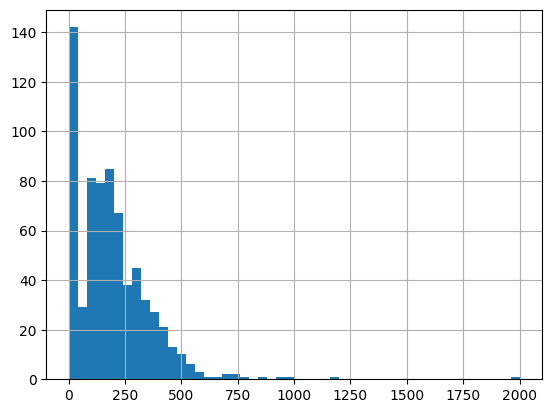

In [27]:
df_raw.groupby('Class')['A13'].mean()
df_raw['A13'].hist(bins=50)

# A14 — Annual Income (Raw Dollars)
Reasoning: Variable with 240 unique values ranging 1–100,001 and by far the largest approval difference of any column at +1,840. Approved applicants earned on average $1,840 more than denied applicants. The range rules out credit score (minimum 300) and income in thousands ($100,001k = implausible). Raw annual dollar income of $1–$100,001 is consistent with the late 1980s timeframe of this dataset.

In [28]:
df_raw.groupby('Class')['A14'].mean()
summary_df[summary_df['column'] == 'A14']

,column,dtype,n_unique,missing,min,max,mean,has_decimals,approved_mean,denied_mean,approval_diff
14,A14,int64,240,0,1.0,100001.0,1018.386,False,2039.86,199.606,1840.254


In [37]:
df = df_raw.copy()

df = df.rename(columns={
    'A1': 'Gender',
    'A2': 'Age',
    'A3': 'Years_Employed',
    'A4': 'Marital_Status',
    'A5': 'Creditworthiness_Tier',
    'A6': 'Occupation',
    'A7': 'Years_at_Address',
    'A8': 'Currently_Employed',
    'A9': 'Prior_Default',
    'A10': 'Debt_Thousands',
    'A11': 'Drivers_License',
    'A12': 'Citizenship_Status',
    'A13': 'Credit Balance',
    'A14': 'Annual_Income'
})

df.head()

from google.colab import files
df.to_csv('Credit_Card_Applications_Labeled.csv', index=False)
files.download('Credit_Card_Applications_Labeled.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

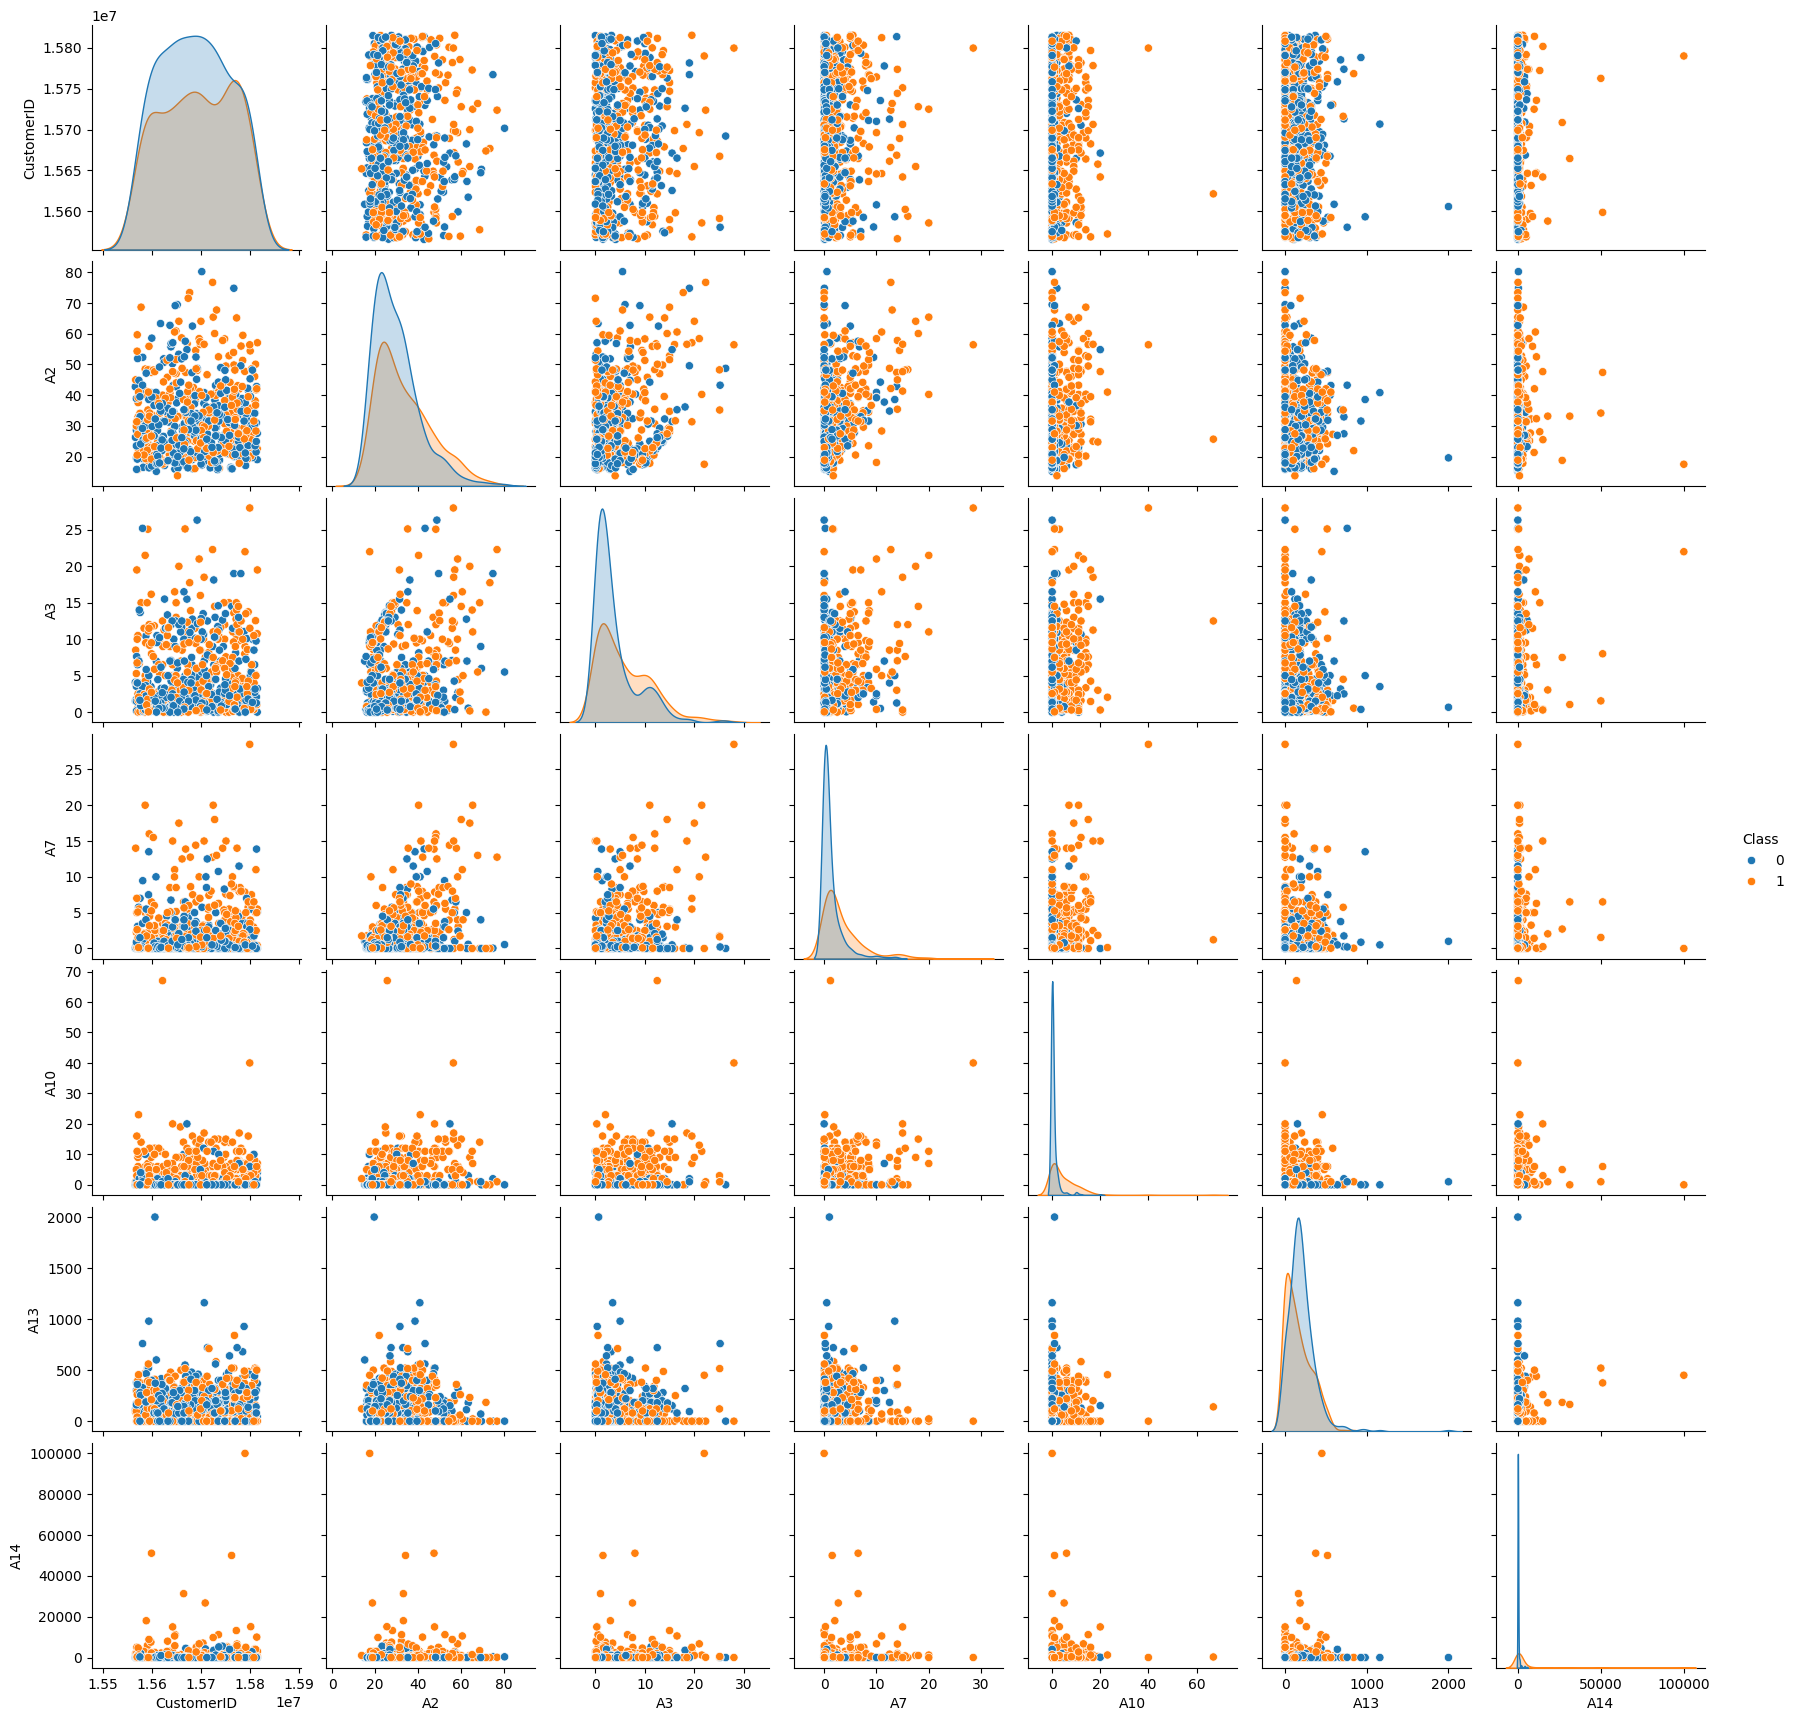

In [36]:
sns.pairplot(data=df_raw[['CustomerID', 'A2', 'A3', 'A7', 'A10', 'A13', 'A14', 'Class']],
             hue='Class');